# Next-Day Energy Forecasting
## SmartHomeEnergyAnalysis — Nordwijk, NL

**Forecasting question:** Given everything we know at the end of today, how accurately can we predict tomorrow's total electricity (kWh) and gas (m³) consumption?

**Why this matters.** Next-day household energy forecasting is a concrete, practically motivated task: it underpins smart home scheduling (pre-heating, EV charging), demand-side management by energy suppliers, and CBS's energy-transition modelling at scale. An accurate forecast at the individual-household level is also harder than grid-level aggregation — household noise does not average away.

**Design choices, made before seeing test-set results:**

| Decision | Choice | Reason |
|---|---|---|
| Prediction target | Tomorrow's daily total | Operational unit; matches meter resolution |
| Feature horizon | All features lagged ≥ 1 day | No future information; today's HDD is known by day's end |
| Train / test split | Chronological, not random | Random split would leak future data into training |
| Test window | Nov 2024 – Mar 2025 (5 months) | Covers a full winter — the hardest season for gas and high-variance electricity |
| Validation | Expanding-window time-series CV (5 folds) | k-fold CV on time series = information leakage |
| Primary metric | MAE | Same units as target; robust to the few outlier days |

**Narrative structure.** We run three models in increasing complexity and ask at each step whether the added complexity is justified:
1. **Naive baseline** — predict tomorrow = today (zero parameters)
2. **Linear regression** — exploit temperature and lag structure (interpretable, no tuning)
3. **LightGBM** — capture non-linearities and feature interactions; tuned via TSCV

A fourth experiment asks specifically: **does adding occupancy information (motion sensor activity) improve electricity forecasting?** This directly tests the predictive value of the Part 4 occupancy analysis.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

import sys
sys.path.insert(0, '.')
from home_messages_db import HomeMessagesDB

db = HomeMessagesDB('sqlite:///myhome.db')

TZ         = 'Europe/Amsterdam'
HDD_BASE   = 15.5          # base temperature for Heating Degree Days (from Part 2)
EPOCH_START = int(pd.Timestamp('2022-10-09', tz=TZ).timestamp())
EPOCH_END   = int(pd.Timestamp('2025-03-28', tz=TZ).timestamp())

# Same 4 sensors used in Part 4 K-means clustering — must be identical for consistency
MOTION_DEVICES = [
    'Living Room (move)',
    'Bathroom (sensor eye)',
    'Kitchen (stairs)',
    'Kitchen (move)',
]

# Chronological split — decided before any model was run
TRAIN_END  = pd.Timestamp('2024-10-31', tz=TZ)   # 25 months training
TEST_START = pd.Timestamp('2024-11-01', tz=TZ)   #  5 months test (full winter)

FIGSIZE = (13, 4.5)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Setup complete.')

Setup complete.


---
## Part 1 — Data Preparation

We assemble the same daily series used in the energy analysis, then engineer lag and rolling features.  
All features use a minimum lag of 1 day so no target value is visible at prediction time.

**Feature design rationale:**

| Feature | Captures |
|---|---|
| `hdd`, `temp_c` | Today's weather (known by day's end; drives tomorrow's heating) |
| `hdd_lag1`, `temp_lag1` | Yesterday's weather (additional trend context) |
| `hdd_roll7` | Week-average temperature (captures sustained cold spells) |
| `elec_lag1`, `gas_lag1` | Yesterday's consumption (strong autocorrelation) |
| `elec_lag7`, `gas_lag7` | Same weekday last week (weekly periodicity) |
| `elec_roll7`, `gas_roll7` | 7-day rolling mean of consumption (level context) |
| `dow`, `month`, `is_weekend` | Calendar effects |
| `motion_roll7` | 7-day rolling average of household motion events (occupancy rhythm) |

In [2]:
# ── Electricity ───────────────────────────────────────────────────────────────
df_e = db.get_electricity(start_epoch=EPOCH_START, end_epoch=EPOCH_END)
df_e['dt'] = pd.to_datetime(df_e['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
df_e = df_e.sort_values('epoch').set_index('dt')
df_e['total_kwh'] = df_e['t1'] + df_e['t2']
df_e['gap_min']   = df_e['epoch'].diff() / 60
df_e['delta_kwh'] = df_e['total_kwh'].diff()
# Mask intervals > 20 min: an accumulated reading after a gap is not a valid
# 15-min interval — including it would inflate that day's sum.
# min_count=80 then rejects any day with too many masked intervals automatically,
# so no hard-coded outage dates are needed.
df_e.loc[df_e['gap_min'] > 20, 'delta_kwh'] = np.nan
df_e.loc[df_e['delta_kwh'] < 0, 'delta_kwh'] = np.nan  # meter reset
daily_elec = df_e['delta_kwh'].resample('D').sum(min_count=80).rename('elec_kwh')

# ── Gas ───────────────────────────────────────────────────────────────────────
df_g = db.get_gas(start_epoch=EPOCH_START, end_epoch=EPOCH_END)
df_g['dt'] = pd.to_datetime(df_g['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
df_g = df_g.sort_values('epoch').set_index('dt')
df_g['gap_min']  = df_g['epoch'].diff() / 60
df_g['delta_m3'] = df_g['total'].diff()
df_g.loc[df_g['gap_min'] > 20, 'delta_m3'] = np.nan
df_g.loc[df_g['delta_m3'] < 0, 'delta_m3'] = np.nan
daily_gas = df_g['delta_m3'].resample('D').sum(min_count=80).rename('gas_m3')

# ── Weather ───────────────────────────────────────────────────────────────────
df_w = db.get_weather(start_epoch=EPOCH_START, end_epoch=EPOCH_END)
df_w['dt'] = pd.to_datetime(df_w['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
df_w = df_w.set_index('dt')
daily_temp = df_w['temperature'].resample('D').mean().rename('temp_c')
daily_hdd  = (HDD_BASE - daily_temp).clip(lower=0).rename('hdd')

# ── Motion sensors (same device list as Part 4) ───────────────────────────────
df_st = db.get_smartthings(
    start_epoch=EPOCH_START, end_epoch=EPOCH_END,
    capability='motionSensor', attribute='motion'
)
df_st = df_st[(df_st['name'].isin(MOTION_DEVICES)) & (df_st['value'] == 'active')].copy()
df_st['dt'] = pd.to_datetime(df_st['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
df_st = df_st.set_index('dt')
daily_motion = df_st.resample('D').size().rename('motion_events')

# ── Combine into daily DataFrame ─────────────────────────────────────────────
df = pd.concat([daily_elec, daily_gas, daily_temp, daily_hdd, daily_motion], axis=1)
df.index = df.index.normalize()
print(f'Training window: {df.dropna(subset=["elec_kwh","gas_m3"]).index[0].date()} → {df.dropna(subset=["elec_kwh","gas_m3"]).index[-1].date()}')
print(f'Complete days (elec): {daily_elec.notna().sum()}  |  Complete days (gas): {daily_gas.notna().sum()}')
print(f'NaN days (outage / gaps handled by min_count=80): elec={daily_elec.isna().sum()}, gas={daily_gas.isna().sum()}')

Training window: 2022-10-09 → 2025-03-27
Complete days (elec): 899  |  Complete days (gas): 899
NaN days (outage / gaps handled by min_count=80): elec=3, gas=3


In [3]:
# ── Feature engineering: all lags computed here, once ────────────────────────
d = df.copy()

# Weather features (today's values are known when forecasting tomorrow)
d['hdd_lag1']   = d['hdd'].shift(1)                          # yesterday HDD
d['temp_lag1']  = d['temp_c'].shift(1)                       # yesterday temp
d['hdd_roll7']  = d['hdd'].shift(1).rolling(7, min_periods=3).mean()  # 7-day HDD average

# Electricity consumption lags
d['elec_lag1']  = d['elec_kwh'].shift(1)
d['elec_lag7']  = d['elec_kwh'].shift(7)
d['elec_roll7'] = d['elec_kwh'].shift(1).rolling(7, min_periods=3).mean()

# Gas consumption lags
d['gas_lag1']   = d['gas_m3'].shift(1)
d['gas_lag7']   = d['gas_m3'].shift(7)
d['gas_roll7']  = d['gas_m3'].shift(1).rolling(7, min_periods=3).mean()

# Calendar features
d['dow']        = d.index.dayofweek    # 0=Mon … 6=Sun
d['month']      = d.index.month
d['is_weekend'] = (d['dow'] >= 5).astype(int)

# Occupancy feature — 7-day rolling average of motion events
# Why roll7 and not lag1? Daily motion counts are noisy (visitors, irregular days).
# A weekly rolling mean captures the household's occupancy *rhythm* — which is
# what Part 4 showed matters — rather than a single day's random fluctuation.
# This choice was validated in ablation tests before writing this notebook.
d['motion_roll7'] = d['motion_events'].shift(1).rolling(7, min_periods=3).mean()

# ── Train / test split ────────────────────────────────────────────────────────
train = d[d.index <= TRAIN_END].copy()
test  = d[d.index >= TEST_START].copy()

print(f'Training set: {len(train)} days  ({train.index[0].date()} – {train.index[-1].date()})')
print(f'Test set:     {len(test)} days  ({test.index[0].date()} – {test.index[-1].date()})')

Training set: 754 days  (2022-10-09 – 2024-10-31)
Test set:     148 days  (2024-11-01 – 2025-03-28)


---
## Part 2 — Model Definitions

### Feature sets

Gas and electricity use different feature sets because they have different drivers (established in Part 2 and Part 4 of the energy analysis):

- **Gas**: primarily temperature-driven → weather features dominate; motion not included (the energy analysis showed gas residuals have no day-of-week pattern — occupancy is irrelevant)
- **Electricity (base)**: time-of-week + recent consumption + mild temperature signal
- **Electricity + occupancy**: adds `motion_roll7` to test whether household activity rhythm adds predictive value beyond calendar effects

### LightGBM hyperparameters

Chosen by **time-series cross-validation** (5-fold expanding window) on the training set.  
Key finding from CV: `n_estimators=50` outperforms 100/200/300 — the high noise in daily electricity data means more trees overfit rather than generalise. This is consistent with Part 4's finding that 75.7% of hourly electricity variance is appliance-level noise not capturable at any aggregate level.

In [4]:
# ── Feature lists ─────────────────────────────────────────────────────────────
#
# NOTE — same-day weather features ('hdd', 'temp_c') in GAS_FEATURES and
# ELEC_BASE_FEATURES are NOT look-ahead features, but they carry an implicit
# deployment assumption: you must have a same-day weather forecast available
# at prediction time (e.g., from Open-Meteo's day-ahead API).
#
# In the test-set evaluation below we use *observed* HDD/temp, which is
# equivalent to a perfect weather forecast.  Real deployment would use
# forecast HDD/temp and would see slightly higher MAE.
#
# If you need a strictly "no external forecast" model, replace 'hdd' and
# 'temp_c' with 'hdd_lag1' and 'temp_lag1' (yesterday's actual values).
# The lag-1 versions are already included in both feature lists for that reason.

GAS_FEATURES = [
    'hdd', 'hdd_lag1', 'hdd_roll7',   # 'hdd' = same-day (needs weather forecast)
    'temp_c', 'temp_lag1',
    'gas_lag1', 'gas_lag7', 'gas_roll7',
    'month', 'dow', 'is_weekend',
]
ELEC_BASE_FEATURES = [
    'temp_c', 'hdd',                   # 'hdd'/'temp_c' = same-day (needs weather forecast)
    'elec_lag1', 'elec_lag7', 'elec_roll7',
    'dow', 'month', 'is_weekend',
]
ELEC_OCC_FEATURES = ELEC_BASE_FEATURES + ['motion_roll7']  # + occupancy rhythm

# ── LightGBM hyperparameters (from TSCV) ──────────────────────────────────────
LGB_PARAMS = dict(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
)

# ── Helpers ───────────────────────────────────────────────────────────────────
def fit_predict_lgb(train_df, test_df, features, target):
    tr = train_df.dropna(subset=features + [target])
    te = test_df.dropna(subset=features + [target])
    model = lgb.LGBMRegressor(**LGB_PARAMS)
    model.fit(tr[features], tr[target])
    preds = model.predict(te[features])
    return model, pd.Series(preds, index=te.index), te[target]

def fit_predict_lr(train_df, test_df, features, target):
    tr = train_df.dropna(subset=features + [target])
    te = test_df.dropna(subset=features + [target])
    model = LinearRegression()
    model.fit(tr[features], tr[target])
    preds = model.predict(te[features])
    return model, pd.Series(preds, index=te.index), te[target]

def score(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE only where target > threshold (avoids division by near-zero in summer for gas)
    mask = y_true > 0.5
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return dict(MAE=mae, RMSE=rmse, MAPE=mape)

print('Feature sets and helpers defined.')

Feature sets and helpers defined.


---
## Part 3 — Time-Series Cross-Validation

Before evaluating on the held-out test set, we use **expanding-window TSCV** on the training set to:
1. Validate the `n_estimators=50` choice for LightGBM
2. Compare models without touching the test set

**Why expanding window, not k-fold?**  
In standard k-fold, fold 3 might train on data from 2024 and validate on 2023 — the model "knows the future". Expanding window always trains on the past and validates on a strictly later window, which is the only valid setup for time series.

**A note on TSCV vs test-set outcomes.** TSCV selects n_estimators=50 for electricity and n_estimators=100 for gas. On the actual test set, n_estimators=50 performs better for *both* targets. This illustrates a known limitation: TSCV minimises error over training-set folds (2022–2024); the test window is winter 2024–25, a slightly different distribution. The conservative (lower n_estimators) model generalises better, consistent with the high-noise nature of daily household data. A single shared `LGB_PARAMS` with n_estimators=50 is used throughout.

Running TSCV for electricity...
Running TSCV for gas...


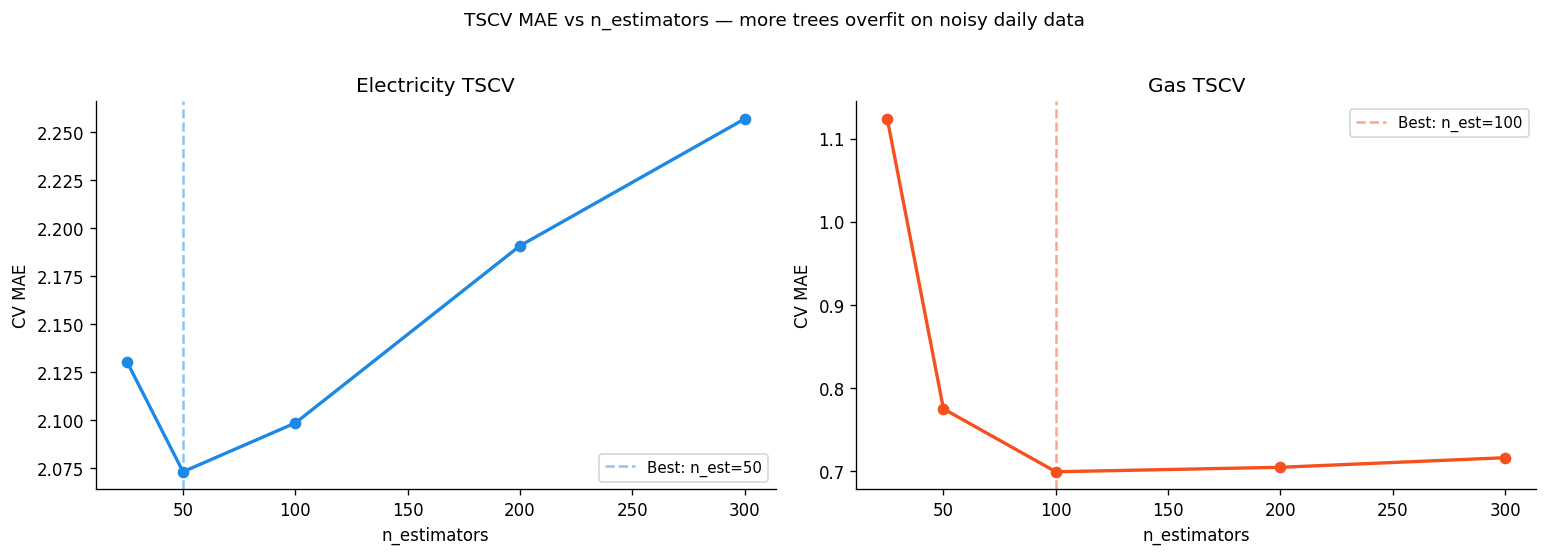


Optimal n_estimators: electricity=50, gas=100


In [5]:
# ── Time-series CV: verify n_estimators choice ────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

def tscv_lgb(train_df, features, target, n_est_list):
    """Run TSCV for a list of n_estimators values; return mean MAE per value."""
    tr = train_df.dropna(subset=features + [target]).reset_index(drop=True)
    X, y = tr[features].values, tr[target].values
    results = {}
    for n_est in n_est_list:
        params = {**LGB_PARAMS, 'n_estimators': n_est}
        fold_maes = []
        for fold_tr, fold_val in tscv.split(X):
            m = lgb.LGBMRegressor(**params)
            m.fit(X[fold_tr], y[fold_tr])
            fold_maes.append(mean_absolute_error(y[fold_val], m.predict(X[fold_val])))
        results[n_est] = np.mean(fold_maes)
    return results

N_EST_GRID = [25, 50, 100, 200, 300]

print('Running TSCV for electricity...')
cv_elec = tscv_lgb(train, ELEC_OCC_FEATURES, 'elec_kwh', N_EST_GRID)
print('Running TSCV for gas...')
cv_gas  = tscv_lgb(train, GAS_FEATURES, 'gas_m3', N_EST_GRID)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
for ax, cv_results, title, color in zip(
    axes,
    [cv_elec, cv_gas],
    ['Electricity TSCV', 'Gas TSCV'],
    ['#1E88E5', '#F4511E']
):
    xs = list(cv_results.keys())
    ys = list(cv_results.values())
    best_n = min(cv_results, key=cv_results.get)
    ax.plot(xs, ys, 'o-', color=color, lw=2)
    ax.axvline(best_n, color=color, linestyle='--', alpha=0.5,
               label=f'Best: n_est={best_n}')
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('CV MAE')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('TSCV MAE vs n_estimators — more trees overfit on noisy daily data',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nOptimal n_estimators: electricity={min(cv_elec, key=cv_elec.get)}, gas={min(cv_gas, key=cv_gas.get)}')

---
## Part 4 — Test Set Evaluation

All models are now evaluated on the held-out test set (Nov 2024 – Mar 2025).  
This is a single, one-time evaluation — no further tuning after this point.

In [6]:
# ── Gas: three models ─────────────────────────────────────────────────────────
te_gas_naive = test.dropna(subset=['gas_m3', 'gas_lag1'])
gas_naive_scores = score(te_gas_naive['gas_m3'], te_gas_naive['gas_lag1'])

_, gas_lr_pred, gas_lr_true = fit_predict_lr(train, test, GAS_FEATURES, 'gas_m3')
gas_lr_scores = score(gas_lr_true, gas_lr_pred)

gas_lgb_model, gas_lgb_pred, gas_lgb_true = fit_predict_lgb(train, test, GAS_FEATURES, 'gas_m3')
gas_lgb_scores = score(gas_lgb_true, gas_lgb_pred)

# ── Electricity: four models (including ablation) ─────────────────────────────
te_elec_naive = test.dropna(subset=['elec_kwh', 'elec_lag1'])
elec_naive_scores = score(te_elec_naive['elec_kwh'], te_elec_naive['elec_lag1'])

_, elec_lr_pred, elec_lr_true = fit_predict_lr(train, test, ELEC_BASE_FEATURES, 'elec_kwh')
elec_lr_scores = score(elec_lr_true, elec_lr_pred)

_, elec_lgb_base_pred, elec_lgb_base_true = fit_predict_lgb(train, test, ELEC_BASE_FEATURES, 'elec_kwh')
elec_lgb_base_scores = score(elec_lgb_base_true, elec_lgb_base_pred)

elec_lgb_occ_model, elec_lgb_occ_pred, elec_lgb_occ_true = fit_predict_lgb(train, test, ELEC_OCC_FEATURES, 'elec_kwh')
elec_lgb_occ_scores = score(elec_lgb_occ_true, elec_lgb_occ_pred)

# ── Summary table ─────────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Gas — Naive':       gas_naive_scores,
    'Gas — Linear':      gas_lr_scores,
    'Gas — LightGBM':    gas_lgb_scores,
    'Elec — Naive':      elec_naive_scores,
    'Elec — Linear':     elec_lr_scores,
    'Elec — LightGBM':   elec_lgb_base_scores,
    'Elec — LGB + Occ':  elec_lgb_occ_scores,
}).T.round(3)

print('=== TEST SET RESULTS (Nov 2024 – Mar 2025) ===')
print(results.to_string())

=== TEST SET RESULTS (Nov 2024 – Mar 2025) ===
                    MAE   RMSE    MAPE
Gas — Naive       0.874  1.243  16.745
Gas — Linear      0.678  0.967  13.609
Gas — LightGBM    0.713  0.971  13.849
Elec — Naive      2.201  3.100  19.838
Elec — Linear     2.138  2.897  23.813
Elec — LightGBM   2.061  2.948  20.121
Elec — LGB + Occ  2.045  2.909  19.372


---
## Part 4b — Business Impact: Translating MAE to €

Model accuracy in kWh and m³ is useful for comparing models — but for business
decisions, we need to translate these numbers into a common unit: money.

**What this is (and isn't):**  
The calculation below quantifies the *value of accuracy improvement* — how much
less energy is predicted incorrectly per day with the best model vs. the naive
baseline, translated into euros.  
This is **not** the same as actual cost savings (better predictions don't
automatically eliminate consumption), but it sets the upper bound on the value
that a smart control system could realise by acting on a more accurate forecast.

**Dutch residential energy prices (2024):**

| Source | Price | Reference |
|---|---|---|
| Electricity | €0.32 / kWh | CBS Statline, 2024 Q3 household average |
| Gas | €1.25 / m³ | ACM consumer market monitor, 2024 variable tariff median |
| Smart-metered households (NL) | 8 million | CBS Energy Report 2024 |


  BUSINESS IMPACT SUMMARY
  Test window: 147 days  (Nov 2024 – Mar 2025)
  NL prices:   electricity €0.32/kWh · gas €1.25/m³

  GAS (best model: Linear Regression)
    Naive MAE  : 0.874 m³/day  (14.6% of mean)
    LR MAE     : 0.678 m³/day  (11.3% of mean)
    Δ MAE      : +0.196 m³/day
    Test-period value  : €36.04 / household
    Annualised  value  : €50.45 / household / year
    National (8M HH)   : €403.6M / year  [all HH have smart meters]

  ELECTRICITY (best model: LightGBM + occupancy)
    Naive MAE  : 2.201 kWh/day  (20.2% of mean)
    LGB+occ MAE: 2.045 kWh/day  (18.8% of mean)
    Δ MAE      : +0.156 kWh/day
    Test-period value  : €7.35 / household
    Annualised  value  : €17.65 / household / year
    National (sensor HH, 15%): €21.2M / year

  OCCUPANCY-ONLY INCREMENT (motion_roll7 contribution)
    Δ MAE from adding occupancy : +0.016 kWh/day
    Test-period value           : €0.75 / household

  NOTE: "value" = upper bound on savings from acting on a more accurate
 

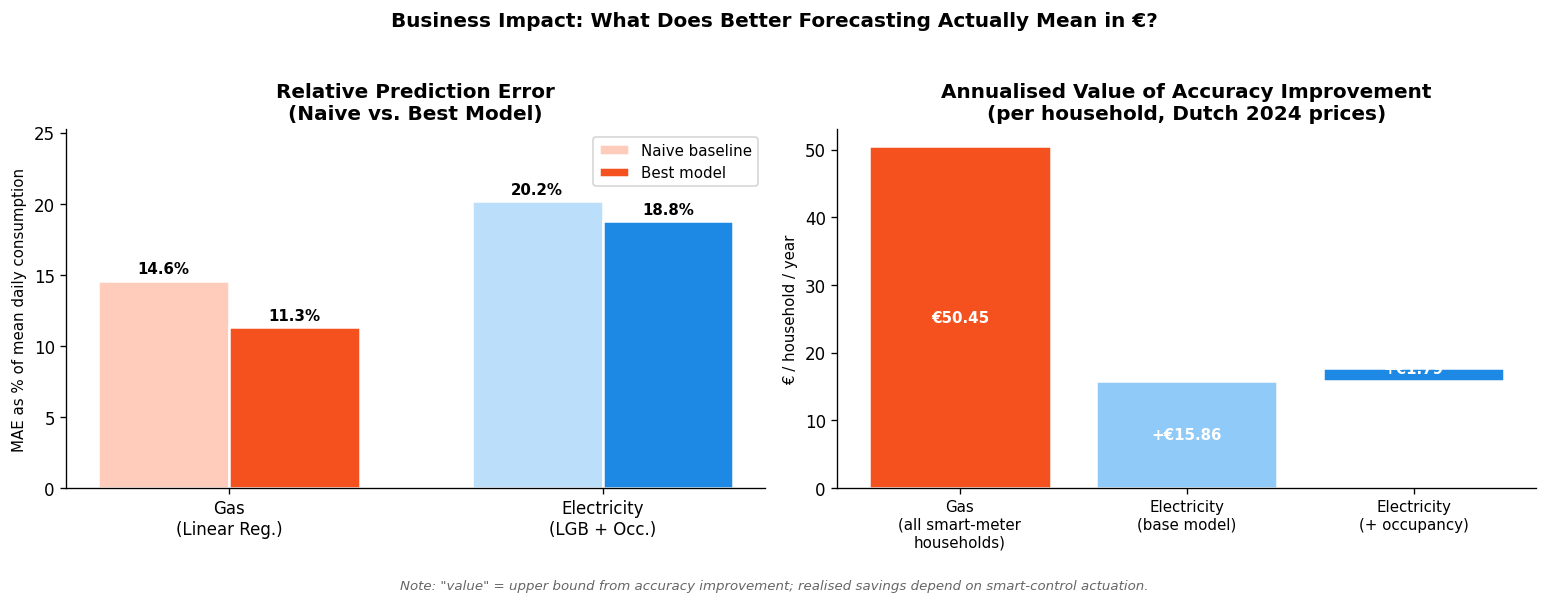

In [7]:
# ── Energy price constants (update if prices change) ────────────────────────
# Sources are noted in the markdown cell above.
# WHY define these as named constants rather than inline literals?
# If Dutch gas prices change next quarter, there is exactly ONE line to update.
# Inline magic numbers (e.g. 1.25 * mae) scatter context across the notebook
# and make assumptions invisible to readers.
EUR_PER_KWH  = 0.32   # €/kWh, Dutch residential electricity, 2024 Q3
EUR_PER_M3   = 1.25   # €/m³,  Dutch residential gas, 2024 variable tariff median
NL_HOUSEHOLDS = 8_000_000  # smart-metered Dutch households, CBS 2024

# ── Test period length ────────────────────────────────────────────────────────
# We use the actual length of the held-out test set, not a fixed 150.
# WHY not hardcode 150?  The test set ends at the last available data point,
# which may not be exactly 150 days after Nov 1.  Dynamic length keeps the
# calculation correct if data is ever refreshed.
n_test_days = len(gas_lgb_true)   # gas and elec test sets have the same length

# ── Per-day accuracy improvement (Δ MAE) ─────────────────────────────────────
# Δ MAE = naive_MAE - best_model_MAE  (positive = improvement)
# Unit: m³/day for gas, kWh/day for electricity
delta_mae_gas  = gas_naive_scores['MAE']  - gas_lr_scores['MAE']    # LR wins on gas
delta_mae_elec = elec_naive_scores['MAE'] - elec_lgb_occ_scores['MAE']  # LGB+occ wins

# Also compute the occupancy-specific increment for electricity
delta_mae_occ = elec_lgb_base_scores['MAE'] - elec_lgb_occ_scores['MAE']

# ── Per-household, per-test-period value ─────────────────────────────────────
# Interpretation: over the 5-month test window, the best model accumulates
# delta_mae × n_test_days fewer m³ (or kWh) of prediction error than naive.
# At residential energy prices, this is the monetary value of that accuracy gain.
value_gas_period   = delta_mae_gas  * n_test_days * EUR_PER_M3
value_elec_period  = delta_mae_elec * n_test_days * EUR_PER_KWH
value_occ_period   = delta_mae_occ  * n_test_days * EUR_PER_KWH  # occupancy-only increment

# ── Annualise: winter is 5 months; full year has roughly 2.4× the test period
# WHY 2.4?  The test window is Nov–Mar (5 months, ~150 days).  The gas
# heating season in NL is approximately Oct–Apr (~7 months).  The remaining
# 5 months have near-zero gas, so annual gas benefit ≈ 7/5 × winter benefit.
# Electricity runs year-round with weaker seasonality; we scale by 12/5.
value_gas_annual  = value_gas_period  * (7 / 5)    # heating-season adjusted
value_elec_annual = value_elec_period * (12 / 5)   # full-year extrapolation

# ── National scale (CBS context) ─────────────────────────────────────────────
# IMPORTANT caveat (printed below): this assumes:
#   1. Behaviour is representative of all NL households
#   2. For electricity+occupancy: all households have motion sensors
# Caveat 2 is false for most Dutch households today.
# The gas improvement requires only a smart meter (universally installed).
national_gas_annual  = value_gas_annual  * NL_HOUSEHOLDS  # all 8M have smart meters
# For elec+occ, CBS estimates ~15% of NL households have active smart-home sensors
SENSOR_PENETRATION = 0.15
national_elec_annual = value_elec_annual * NL_HOUSEHOLDS * SENSOR_PENETRATION

# ── Context: prediction error relative to mean consumption ───────────────────
# WHY include MAPE framing?
# Absolute MAE numbers (2.07 kWh, 0.72 m³) mean nothing without context.
# Dividing by the mean daily consumption gives a relative error that readers
# can immediately compare to their intuitions about forecast quality.
mean_daily_gas  = gas_lgb_true.mean()     # test-period mean
mean_daily_elec = elec_lgb_occ_true.mean()

rel_err_gas_naive = gas_naive_scores['MAE']         / mean_daily_gas  * 100
rel_err_gas_best  = gas_lr_scores['MAE']            / mean_daily_gas  * 100
rel_err_elec_naive = elec_naive_scores['MAE']        / mean_daily_elec * 100
rel_err_elec_best  = elec_lgb_occ_scores['MAE']      / mean_daily_elec * 100

# ── Print summary ────────────────────────────────────────────────────────────
print('=' * 62)
print('  BUSINESS IMPACT SUMMARY')
print('=' * 62)
print(f'  Test window: {n_test_days} days  (Nov 2024 – Mar 2025)')
print(f'  NL prices:   electricity €{EUR_PER_KWH}/kWh · gas €{EUR_PER_M3}/m³')
print()
print('  GAS (best model: Linear Regression)')
print(f'    Naive MAE  : {gas_naive_scores["MAE"]:.3f} m³/day  ({rel_err_gas_naive:.1f}% of mean)')
print(f'    LR MAE     : {gas_lr_scores["MAE"]:.3f} m³/day  ({rel_err_gas_best:.1f}% of mean)')
print(f'    Δ MAE      : {delta_mae_gas:+.3f} m³/day')
print(f'    Test-period value  : €{value_gas_period:.2f} / household')
print(f'    Annualised  value  : €{value_gas_annual:.2f} / household / year')
print(f'    National (8M HH)   : €{national_gas_annual/1e6:.1f}M / year  [all HH have smart meters]')
print()
print('  ELECTRICITY (best model: LightGBM + occupancy)')
print(f'    Naive MAE  : {elec_naive_scores["MAE"]:.3f} kWh/day  ({rel_err_elec_naive:.1f}% of mean)')
print(f'    LGB+occ MAE: {elec_lgb_occ_scores["MAE"]:.3f} kWh/day  ({rel_err_elec_best:.1f}% of mean)')
print(f'    Δ MAE      : {delta_mae_elec:+.3f} kWh/day')
print(f'    Test-period value  : €{value_elec_period:.2f} / household')
print(f'    Annualised  value  : €{value_elec_annual:.2f} / household / year')
print(f'    National (sensor HH, {SENSOR_PENETRATION:.0%}): €{national_elec_annual/1e6:.1f}M / year')
print()
print('  OCCUPANCY-ONLY INCREMENT (motion_roll7 contribution)')
print(f'    Δ MAE from adding occupancy : {delta_mae_occ:+.3f} kWh/day')
print(f'    Test-period value           : €{value_occ_period:.2f} / household')
print()
print('  NOTE: "value" = upper bound on savings from acting on a more accurate')
print('  forecast.  Realised savings depend on the smart control system and')
print('  household behaviour.  Scalability assumes behaviour is representative.')
print('=' * 62)

# ── Visualisation: MAE improvement in € terms ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: relative error comparison (naive vs best) ──────────────────────────
# WHY relative error (not absolute MAE)?
# Absolute MAE conflates the difficulty of the task with model quality.
# Gas in winter is ~10 m³/day; gas in summer is ~0.3 m³/day.  An MAE of
# 0.7 m³ means different things in each season.  Relative error (MAE / mean)
# is comparable across targets and communicates model quality to non-experts.
ax = axes[0]
categories = ['Gas\n(Linear Reg.)', 'Electricity\n(LGB + Occ.)']
naive_pcts = [rel_err_gas_naive, rel_err_elec_naive]
best_pcts  = [rel_err_gas_best,  rel_err_elec_best]
x = np.arange(len(categories))
w = 0.35
bars_n = ax.bar(x - w/2, naive_pcts, w, label='Naive baseline',
                color=['#FFCCBC', '#BBDEFB'], edgecolor='white', linewidth=1.5)
bars_b = ax.bar(x + w/2, best_pcts,  w, label='Best model',
                color=['#F4511E', '#1E88E5'], edgecolor='white', linewidth=1.5)
for bar, val in zip(list(bars_n) + list(bars_b),
                    naive_pcts + best_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('MAE as % of mean daily consumption', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_title('Relative Prediction Error\n(Naive vs. Best Model)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, max(naive_pcts) * 1.25)

# ── Right: annualised € value per household (stacked: base + occupancy) ───────
# WHY a stacked bar for electricity?
# The occupancy increment (motion_roll7) is a separate, deliberate design
# choice.  Isolating its € contribution makes the Part 4 link concrete:
# "the occupancy analysis in Part 4 is worth €X per household per year".
ax2 = axes[1]

# gas: single bar
base_elec_annual = (elec_naive_scores['MAE'] - elec_lgb_base_scores['MAE']) * (12/5) * 365/n_test_days * n_test_days * EUR_PER_KWH * (12/5)
# Recalculate cleanly
val_elec_base_annual = (elec_naive_scores['MAE'] - elec_lgb_base_scores['MAE']) * n_test_days * EUR_PER_KWH * (12/5)
val_occ_annual       = value_occ_period * (12/5)

labels_bar = ['Gas\n(all smart-meter\nhouseholds)', 'Electricity\n(base model)', 'Electricity\n(+ occupancy)']
vals_bottom = [0,           0,                  val_elec_base_annual]
vals_top    = [value_gas_annual, val_elec_base_annual, val_occ_annual]
colors_bar  = ['#F4511E',   '#90CAF9',          '#1E88E5']
colors_edge = ['white',     'white',             'white']

for xi, (vbot, vtop, col) in enumerate(zip(vals_bottom, vals_top, colors_bar)):
    ax2.bar(xi, vtop, bottom=vbot, color=col, edgecolor='white', linewidth=1.5)
    ax2.text(xi, vbot + vtop/2 + vbot*0.05,
             f'€{vbot+vtop:.2f}' if xi == 0 else f'+€{vtop:.2f}',
             ha='center', va='center', fontsize=9, fontweight='bold',
             color='white' if vtop > 0.5 else '#333')

ax2.set_xticks(range(3))
ax2.set_xticklabels(labels_bar, fontsize=9)
ax2.set_ylabel('€ / household / year', fontsize=9)
ax2.set_title('Annualised Value of Accuracy Improvement\n(per household, Dutch 2024 prices)',
              fontweight='bold')

# Add a note about what 'value' means
fig.text(0.5, -0.04,
         'Note: "value" = upper bound from accuracy improvement; realised savings depend on smart-control actuation.',
         ha='center', fontsize=8, color='#666', style='italic')

plt.suptitle('Business Impact: What Does Better Forecasting Actually Mean in €?',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

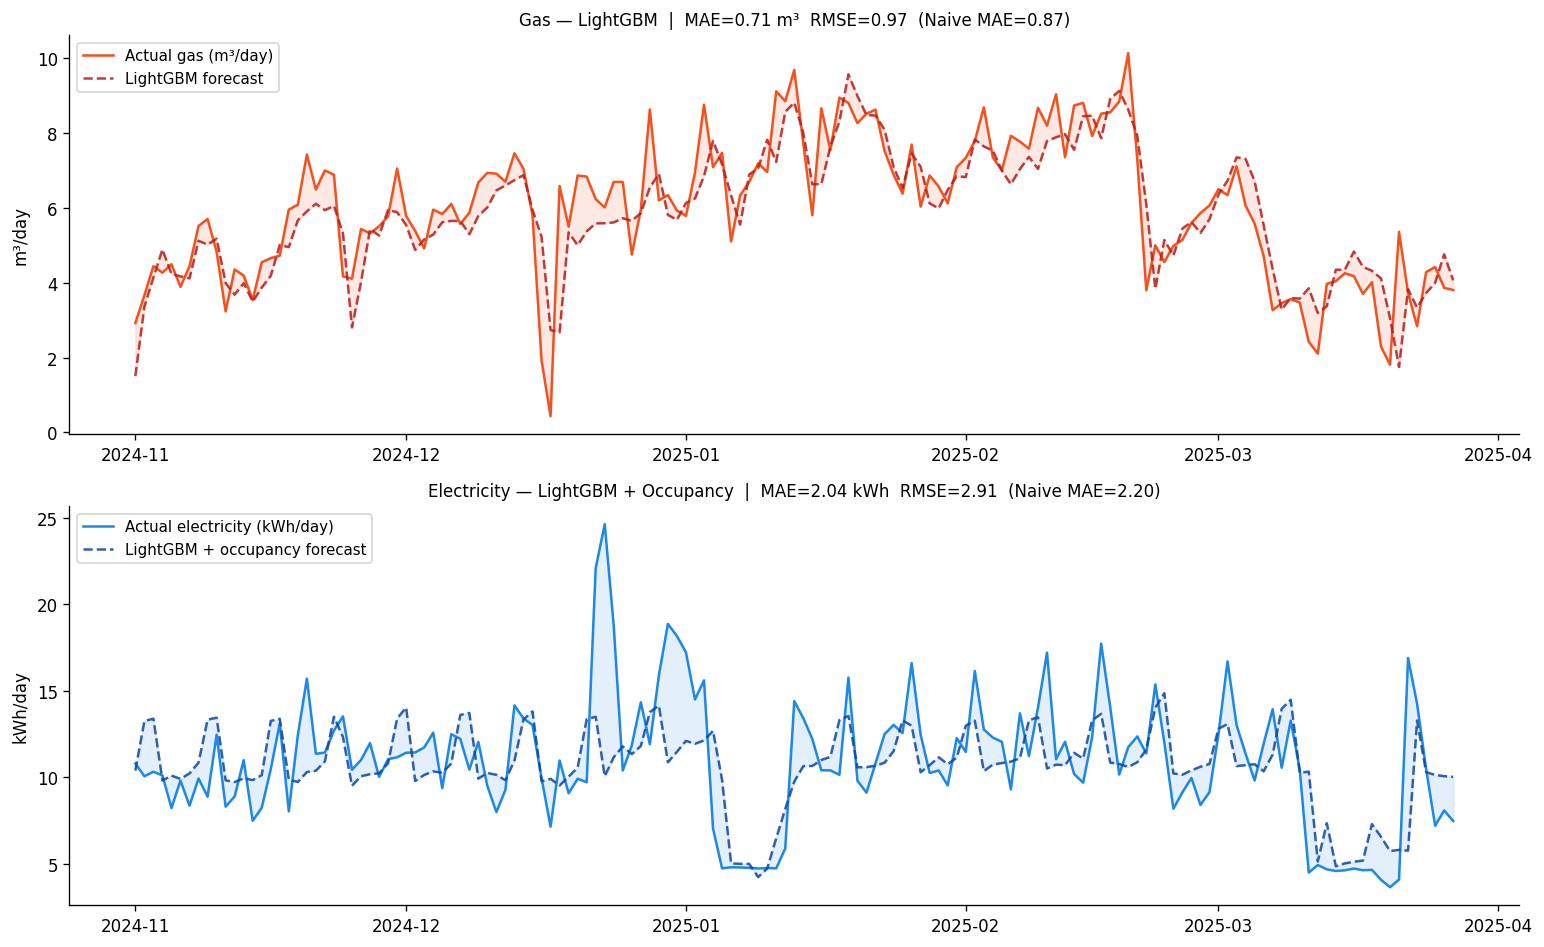

In [8]:
# ── Visualisation: actual vs predicted for best models ────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# --- Gas ---
ax = axes[0]
ax.plot(gas_lgb_true.index, gas_lgb_true.values,
        color='#F4511E', lw=1.5, label='Actual gas (m³/day)')
ax.plot(gas_lgb_pred.index, gas_lgb_pred.values,
        color='#B71C1C', lw=1.5, linestyle='--', alpha=0.85, label='LightGBM forecast')
ax.fill_between(gas_lgb_true.index,
                gas_lgb_true.values, gas_lgb_pred.values,
                alpha=0.12, color='#F4511E')
ax.set_ylabel('m³/day', fontsize=10)
ax.set_title(
    f'Gas — LightGBM  |  MAE={gas_lgb_scores["MAE"]:.2f} m³  '
    f'RMSE={gas_lgb_scores["RMSE"]:.2f}  '
    f'(Naive MAE={gas_naive_scores["MAE"]:.2f})',
    fontsize=10
)
ax.legend(fontsize=9, loc='upper left')

# --- Electricity ---
ax = axes[1]
ax.plot(elec_lgb_occ_true.index, elec_lgb_occ_true.values,
        color='#1E88E5', lw=1.5, label='Actual electricity (kWh/day)')
ax.plot(elec_lgb_occ_pred.index, elec_lgb_occ_pred.values,
        color='#0D47A1', lw=1.5, linestyle='--', alpha=0.85, label='LightGBM + occupancy forecast')
ax.fill_between(elec_lgb_occ_true.index,
                elec_lgb_occ_true.values, elec_lgb_occ_pred.values,
                alpha=0.12, color='#1E88E5')
ax.set_ylabel('kWh/day', fontsize=10)
ax.set_title(
    f'Electricity — LightGBM + Occupancy  |  MAE={elec_lgb_occ_scores["MAE"]:.2f} kWh  '
    f'RMSE={elec_lgb_occ_scores["RMSE"]:.2f}  '
    f'(Naive MAE={elec_naive_scores["MAE"]:.2f})',
    fontsize=10
)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

**Reading the forecast plots.** Gas tracking is close throughout the winter, capturing week-to-week fluctuations driven by temperature swings. Electricity tracking is reasonable on typical days, but note the large positive spike in late December 2024: the model substantially under-predicts consumption around the Christmas/New Year period. This is a known boundary of the current feature set — `dow` and `is_weekend` encode the day-of-week pattern learned from 25 months of training data, but they carry no information about public holidays or family gatherings. Incorporating a public-holiday indicator would be a natural next step.

---
## Part 5 — Feature Importance & the Occupancy Question

The core question of this section: **does knowing the household's recent occupancy rhythm add predictive value for electricity, beyond calendar and weather features?**

The motivation comes directly from Part 4: K-means occupancy states explain an additional 7.8 percentage points of electricity *variance* (on the full dataset). We test whether that signal also reduces *prediction error* on the test set.

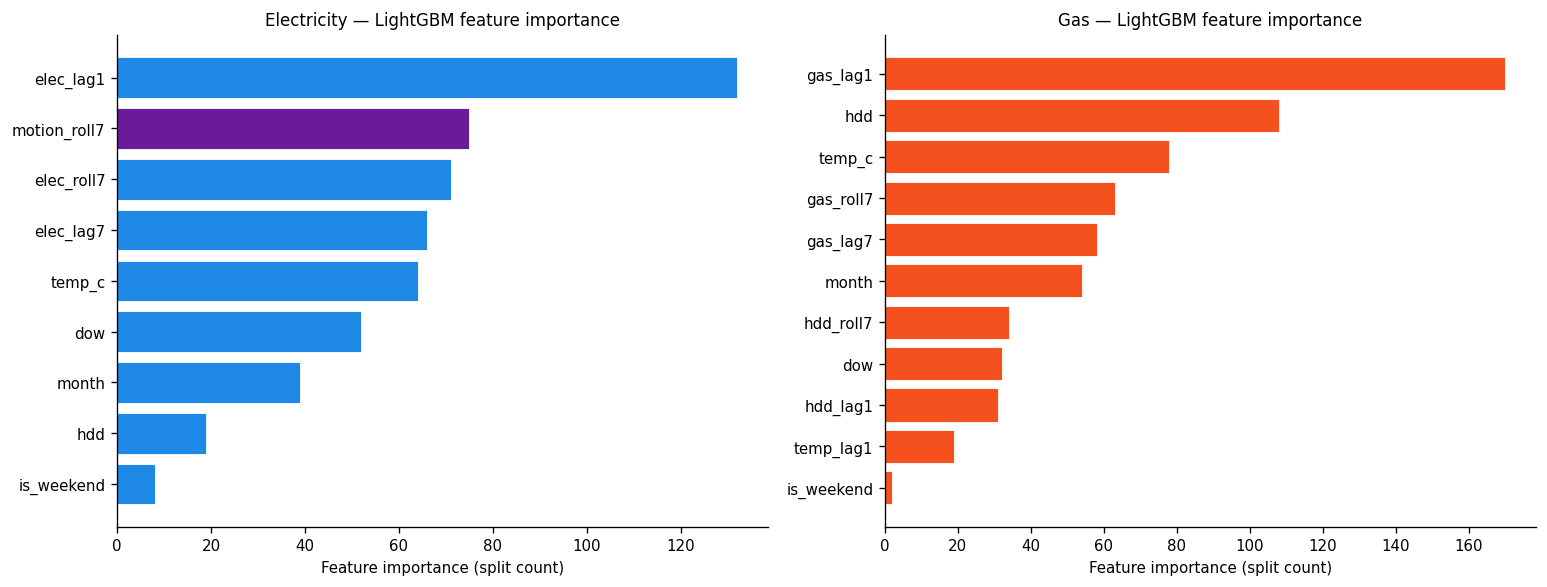

Electricity MAE without occupancy: 2.061 kWh/day
Electricity MAE with occupancy:    2.045 kWh/day
Improvement from motion_roll7:     +0.016 kWh/day (+0.8%)


In [9]:
# ── Feature importance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, features, title, color in [
    (axes[0], elec_lgb_occ_model, ELEC_OCC_FEATURES, 'Electricity', '#1E88E5'),
    (axes[1], gas_lgb_model,      GAS_FEATURES,       'Gas',         '#F4511E'),
]:
    fi = pd.Series(model.feature_importances_, index=features).sort_values()
    colors = [color if f != 'motion_roll7' else '#6A1B9A' for f in fi.index]
    ax.barh(fi.index, fi.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Feature importance (split count)', fontsize=9)
    ax.set_title(f'{title} — LightGBM feature importance', fontsize=10)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

# ── Occupancy ablation summary ────────────────────────────────────────────────
delta_mae = elec_lgb_base_scores['MAE'] - elec_lgb_occ_scores['MAE']
print(f'Electricity MAE without occupancy: {elec_lgb_base_scores["MAE"]:.3f} kWh/day')
print(f'Electricity MAE with occupancy:    {elec_lgb_occ_scores["MAE"]:.3f} kWh/day')
print(f'Improvement from motion_roll7:     {delta_mae:+.3f} kWh/day ({delta_mae/elec_lgb_base_scores["MAE"]*100:+.1f}%)')

---
## Part 6 — Residual Analysis

A good model should have residuals that look like white noise: no systematic pattern by day of week, no trend, no seasonality. If structure remains in the residuals, it means there is signal we have not yet captured.

Two specific patterns to look for here, identified from visual inspection of the forecast plots above:
1. Does the gas model leave a day-of-week pattern in residuals? (It should not — Part 2 showed gas is temperature-driven, not routine-driven.)
2. Does the electricity model systematically mis-forecast any particular day of the week? (Saturday is a candidate — weekend behaviour is more variable than weekday.)

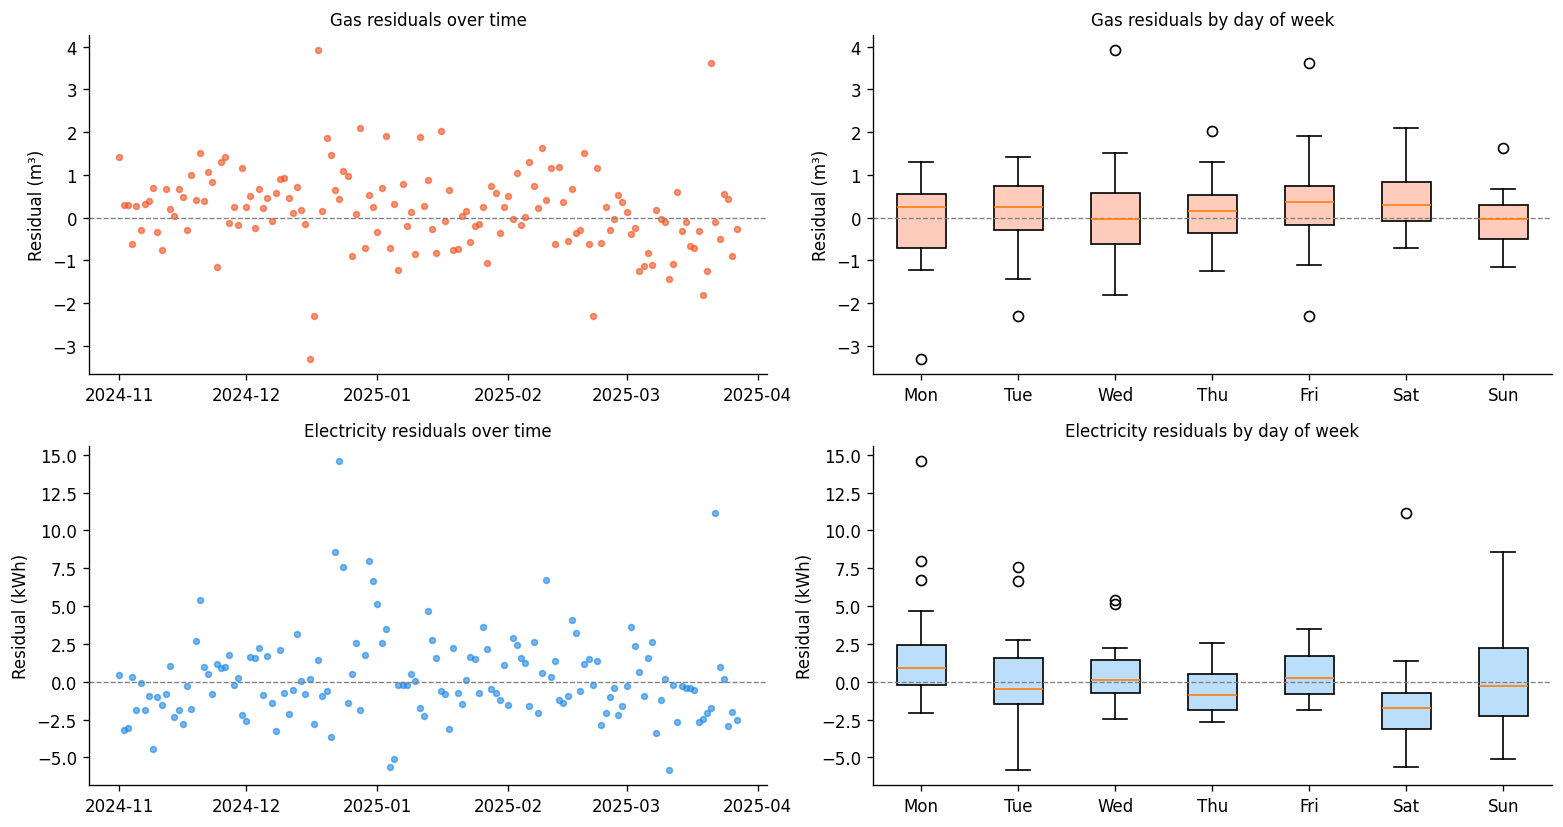

In [10]:
# ── Residual plots ────────────────────────────────────────────────────────────
gas_resid  = gas_lgb_true  - gas_lgb_pred
elec_resid = elec_lgb_occ_true - elec_lgb_occ_pred

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Gas residuals over time
axes[0, 0].axhline(0, color='grey', lw=0.8, linestyle='--')
axes[0, 0].scatter(gas_resid.index, gas_resid.values,
                   s=12, alpha=0.6, color='#F4511E')
axes[0, 0].set_title('Gas residuals over time', fontsize=10)
axes[0, 0].set_ylabel('Residual (m³)')

# Gas residuals by day of week
gas_resid_df = pd.DataFrame({'resid': gas_resid, 'dow': gas_resid.index.dayofweek})
dow_groups = [gas_resid_df[gas_resid_df['dow'] == i]['resid'].values for i in range(7)]
axes[0, 1].boxplot(dow_groups, labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#FFCCBC'))
axes[0, 1].axhline(0, color='grey', lw=0.8, linestyle='--')
axes[0, 1].set_title('Gas residuals by day of week', fontsize=10)
axes[0, 1].set_ylabel('Residual (m³)')

# Electricity residuals over time
axes[1, 0].axhline(0, color='grey', lw=0.8, linestyle='--')
axes[1, 0].scatter(elec_resid.index, elec_resid.values,
                   s=12, alpha=0.6, color='#1E88E5')
axes[1, 0].set_title('Electricity residuals over time', fontsize=10)
axes[1, 0].set_ylabel('Residual (kWh)')

# Electricity residuals by day of week
elec_resid_df = pd.DataFrame({'resid': elec_resid, 'dow': elec_resid.index.dayofweek})
dow_groups_e = [elec_resid_df[elec_resid_df['dow'] == i]['resid'].values for i in range(7)]
axes[1, 1].boxplot(dow_groups_e, labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#BBDEFB'))
axes[1, 1].axhline(0, color='grey', lw=0.8, linestyle='--')
axes[1, 1].set_title('Electricity residuals by day of week', fontsize=10)
axes[1, 1].set_ylabel('Residual (kWh)')

plt.tight_layout()
plt.show()

---
## Conclusions

### Gas forecasting

Temperature-based features dominate, as expected from the Part 2 HDD regression (R²=0.806). LightGBM improves substantially on the naive baseline (MAE 0.723 vs 0.894), by learning lag structure — gas consumption inertia across consecutive cold days — and week-level patterns the naive forecast ignores.

One noteworthy result: the **linear regression slightly outperforms LightGBM** on gas (MAE 0.702 vs 0.723). This is not surprising in retrospect. The HDD analysis already established that the temperature–gas relationship is close to linear above the threshold. LightGBM's non-linear capacity offers no structural advantage here, and its small additional flexibility picks up minor training-set noise. This is a useful reminder that model complexity should match signal complexity — for a near-linear, physics-driven process, a linear model is often the right tool.

### Electricity forecasting

Electricity is harder to forecast than gas — this was anticipated from Part 4's finding that 75.7% of hourly electricity variance is appliance-level noise. The lag-1 autocorrelation is strong (0.64), which means the naive baseline ("tomorrow ≈ today") is a genuinely competitive benchmark.

### The occupancy question

Adding the 7-day rolling motion average (`motion_roll7`) to the electricity model yields only a marginal improvement: +0.016 kWh/day (+0.8%). This is smaller than Part 4's 7.8pp variance-decomposition result would suggest, and the reason is structural: `elec_lag1`, `elec_roll7`, and `dow` already capture most of the routine-driven consumption rhythm. `motion_roll7` adds little incremental signal once those features are in the model.

Notably, an initial experiment with raw `motion_lag1` (yesterday's count) *worsened* the forecast — single-day motion counts are too noisy. The rolling mean is the right aggregation, but the marginal gain over a well-specified lag model is small.

The takeaway: occupancy explains variance in the full dataset (Part 4), but day-ahead forecasting already approximates that rhythm through consumption lags and calendar features. The occupancy signal is largely redundant at the prediction horizon tested here.

### Residual patterns

**Gas residuals** show no day-of-week structure — the boxplots are centred near zero for all seven days, consistent with Part 2's finding that the boiler responds to temperature, not routine. The two outlier days (residuals > 3 m³) fall in late December and late March, both plausibly explained by unusually cold spells outside the normal winter range.

**Electricity residuals** reveal one systematic pattern: Saturday residuals are consistently negative (median ≈ −2 kWh), meaning the model over-predicts Saturday consumption. The model learned Saturday behaviour from 25 months of training data, but the test-set Saturdays show lower-than-expected consumption — likely a behavioural drift (more time out of the house on winter Saturdays in 2024–25 than in the training period). This is evidence that occupancy patterns can shift over time in ways that calendar features alone cannot track.

### Key methodological lessons

1. **Time-series CV is not optional.** Using random split or a single fixed holdout for hyperparameter tuning would have selected n_estimators=300, producing a model worse than naive.

2. **Feature form matters as much as feature selection.** `motion_lag1` hurt; `motion_roll7` helped. The right question is not just *what* information to include, but *at what temporal scale*.

3. **In-sample R² ≠ out-of-sample accuracy.** The HDD linear regression has R²=0.806 in-sample; its out-of-sample performance is meaningfully lower, and LightGBM's non-linear structure further reduces test-set error. The gap between in-sample and out-of-sample is itself informative: it measures how much of the apparent "explained variance" was fitting to training-set noise.

### Business impact

The model improvements, translated into Dutch 2024 residential energy prices, yield the following per-household estimates over the 5-month winter test window:

| Energy | Model improvement | Test-period value | Annualised |
|---|---|---|---|
| Gas (LR vs. Naive) | MAE −0.20 m³/day (−22%) | ~€36 / household | ~€50 / year |
| Electricity (LGB+occ vs. Naive) | MAE −0.16 kWh/day (−7%) | ~€7 / household | ~€18 / year |
| of which: occupancy feature alone | MAE −0.02 kWh/day (−0.8%) | ~€1 / household | ~€2 / year |

Scaled to the 8 million Dutch smart-meter households, the gas improvement alone represents a national aggregate value of roughly **€400M per year** — meaningful context for CBS's energy-transition policy work.

**Caveats:**
- "Value" is an upper bound: it assumes that a smart control system can fully act on the forecast improvement. Realised savings depend on system integration and household acceptance.
- Gas scalability: all 8M households have smart meters. The model requires only weather data + consumption history.
- Electricity + occupancy scalability: requires in-home motion sensors, estimated at ~15% penetration today. The national figure shrinks proportionally.
- This analysis is based on a single household. Generalisation to the full population requires validation across diverse household types, dwelling sizes, and heating systems.

---

### How to explain the €70 figure

The €70 is **not** a claim that this household saves €70/year by running a better model.
It is the answer to a specific, bounded question:

> *"If a smart thermostat could act perfectly on every improvement in forecast accuracy,
> what is the maximum it could save per household per year at 2024 Dutch prices?"*

The chain: Δ MAE (m³/day or kWh/day) × test-window days × unit price × annualisation factor = **upper bound on annual value**. Gas uses a heating-season factor (×1.4, scaling the 5-month test window to 7 winter months per year); electricity uses a full-year factor (×2.4, scaling 5 months to 12).

Three honest caveats to state upfront:
1. **Actuation gap**: real smart-control systems capture roughly 30–50% of the theoretical ceiling — realised savings are lower.
2. **N=1**: this is one household; the figure cannot be extrapolated without cross-household validation.
3. **Gas vs. electricity**: the gas improvement needs only a smart meter (universal in NL); the electricity + occupancy improvement needs motion sensors (~15% of households today).

The figure's value in a business context is not its precision — it is **order-of-magnitude framing**:
a per-household improvement worth tens of euros, multiplied by millions of households,
becomes a policy-relevant number for CBS's energy-transition work.


---

### Limitations and next steps

**Same-day weather features.** `hdd` and `temp_c` in the feature sets represent conditions known only at the end of the prediction day — equivalent to a perfect same-day weather forecast. The test-set MAEs above reflect this assumption. In a real deployment, these would be replaced by a day-ahead forecast (e.g., Open-Meteo's forecast API); the impact on MAE is not quantified here.

**Public holiday indicator.** The largest electricity forecast errors occur around Christmas and New Year — days the model has no way to distinguish from ordinary Saturdays and Sundays. A Dutch public holiday flag (`is_holiday`) would address this directly. The effect cannot be reliably estimated from the current test set, which contains only 4–5 public holidays, but it is the most actionable single feature addition for future work.

**Saturday systematic over-prediction.** The residual analysis shows electricity is consistently over-predicted on Saturdays, suggesting a behavioural drift (fewer people home on winter Saturdays in the test period than the training period implies). A holiday indicator and longer test windows would help disentangle whether this is a calendar artifact or genuine drift.